In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
#diffusers is a hugging face page for using diffusion models from huggingface hub
!pip install diffusers transformers accelerate

In [3]:
from diffusers import StableDiffusionPipeline
import matplotlib.pyplot as plt
import torch

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


In [4]:
model_id1 = "dreamlike-art/dreamlike-diffusion-1.0"

In [5]:
pipe = StableDiffusionPipeline.from_pretrained(model_id1, torch_dtype=torch.float16, use_safetensors=True)
pipe = pipe.to("cuda")

model_index.json:   0%|          | 0.00/511 [00:00<?, ?B/s]

Fetching 13 files:   0%|          | 0/13 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/5 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--dreamlike-art--dreamlike-diffusion-1.0/snapshots/9fb5a6463bf79d81152e715e8d2a8b988f96c790/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [6]:
prompt = """dreamlikeart, a grungy woman with rainbow hair, travelling between dimensions, dynamic pose, happy, soft eyes and narrow chin,
extreme bokeh, dainty figure, long hair straight down, torn kawaii shirt and baggy jeans
"""

In [7]:
prompt = """cyberpunk dimension traveler girl with rainbow hair, grunge aesthetic, dynamic pose jumping through a neon portal, happy smile, soft dreamy eyes, narrow chin, long straight hair flowing, torn kawaii shirt and oversized baggy jeans, neon lights, holographic particles, extreme bokeh, cinematic lighting, ultra detailed digital art"""

In [8]:
image = pipe(prompt).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

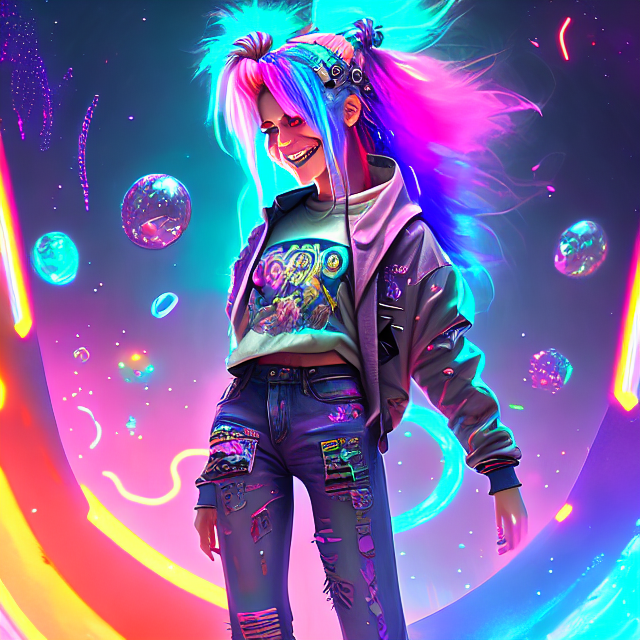

In [9]:
image

In [10]:
prompt2 = """an astronaut standing on an alien planet, giant glowing rings in the sky, purple mountains and cosmic clouds, reflective space suit visor, dramatic lighting, cinematic science fiction scene, ultra detailed, volumetric lighting, 8k masterpiece"""
image = pipe(prompt2).images[0]

  0%|          | 0/50 [00:00<?, ?it/s]

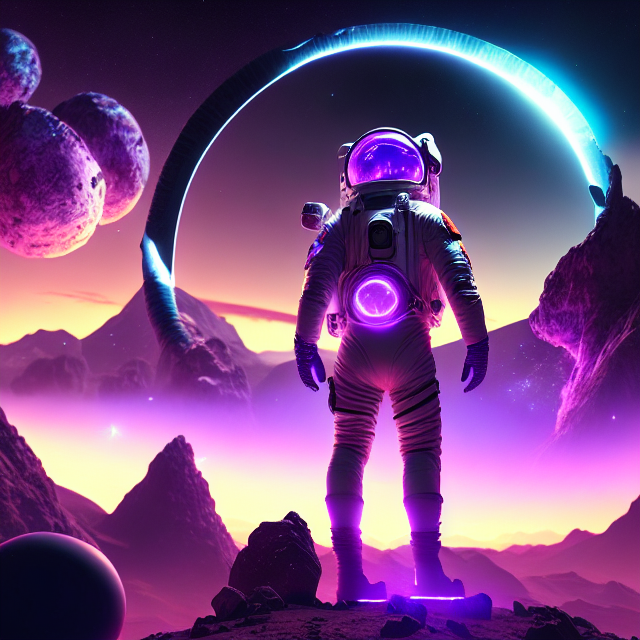

In [11]:
image

Working with Stable Diffusion parameters
* Negative prompting

* num_inference_steps

* height\n

weight
num_images_per_prompt

In [12]:
def generate_image(pipe, prompt, params):
  img = pipe(prompt, **params).images

  num_images = len(img)
  if num_images>1:
    fig, ax = plt.subplots(nrows=1, ncols=num_images)
    for i in range(num_images):
      ax[i].imshow(img[i]);
      ax[i].axis('off');

  else:
    fig = plt.figure()
    plt.imshow(img[0]);
    plt.axis('off');
  plt.tight_layout()

In [13]:
prompt = "photorealistic portrait of a young man with soft natural lighting, sharp facial details, shallow depth of field, DSLR photography, 85mm lens, studio portrait, ultra detailed skin texture, 8k resolution"

params = {}

  0%|          | 0/50 [00:00<?, ?it/s]

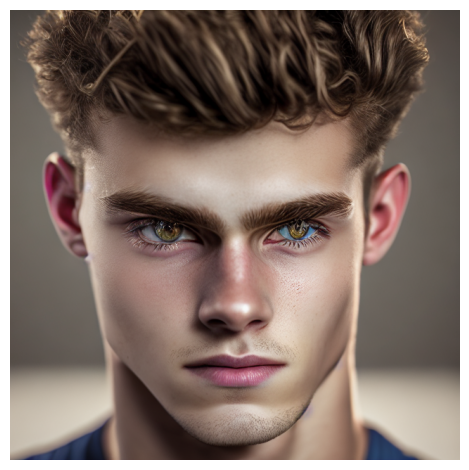

In [14]:
generate_image(pipe, prompt, params)

In [15]:
params = {
    "negative_prompt": "blurry, low quality, bad anatomy, extra fingers",
    "num_inference_steps": 30,
    "guidance_scale": 7.5,
    "height": 512,
    "width": 512,
    "num_images_per_prompt": 4
}

  0%|          | 0/30 [00:00<?, ?it/s]

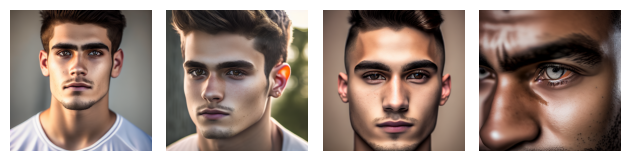

In [16]:
generate_image(pipe, prompt, params)

  0%|          | 0/30 [00:00<?, ?it/s]

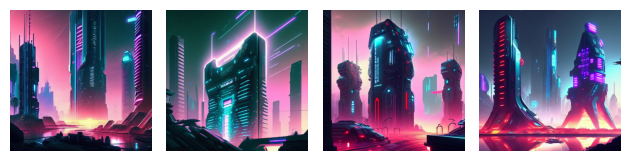

In [17]:
prompt = "a futuristic cyberpunk city at night"

params = {
    "negative_prompt": "blurry, low quality, distorted face",
    "num_inference_steps": 30,
    "height": 512,
    "width": 512,
    "num_images_per_prompt": 4
}

generate_image(pipe, prompt, params)

# Text_to_speech_generation

In [18]:
from transformers import pipeline

In [19]:
text = "Python is a high-level, general-purpose programming language."

pipe = pipeline("text-to-speech", model="suno/bark-small", device="cuda")

output = pipe(text)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/542 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/1.68G [00:00<?, ?B/s]

The tied weights mapping and config for this model specifies to tie fine_acoustics.input_embeds_layers.1.weight to fine_acoustics.lm_heads.0.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie fine_acoustics.input_embeds_layers.2.weight to fine_acoustics.lm_heads.1.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie fine_acoustics.input_embeds_layers.3.weight to fine_acoustics.lm_heads.2.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie fine_acoustics.input_embeds_l

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

speaker_embeddings_path.json: 0.00B [00:00, ?B/s]

Passing `generation_config` together with generation-related arguments=({'return_dict_in_generate', 'min_eos_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:10000 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Both `max_new_tokens` (=768) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


In [20]:
from IPython.display import Audio

Audio(output["audio"], rate=output["sampling_rate"])